In [1]:
import pandas as pd

In [10]:
df = pd.read_csv('/content/cleaned_rainfall.csv')


In [11]:
df

,id,date,state_code,state_name,actual,rfs,normal,deviation
0,0,2009-01-01,5,Uttarakhand,0.000000,0.003906,2.19,-100.000000
1,1,2009-01-01,18,Assam,0.000000,0.000000,0.52,-100.000000
2,2,2009-01-01,16,Tripura,0.000000,0.000000,0.09,-100.000000
3,3,2009-01-01,36,Telangana,0.000000,0.000000,0.17,-100.000000
4,4,2009-01-01,2,Himachal Pradesh,0.000000,0.008566,3.31,-100.000000
...,...,...,...,...,...,...,...,...
204871,204871,2024-07-27,38,The Dadra And Nagar Haveli And Daman And Diu,3.990693,0.000000,7.40,38.516222
204872,204872,2024-07-28,38,The Dadra And Nagar Haveli And Daman And Diu,3.990693,0.000000,8.30,38.516222
204873,204873,2024-07-29,38,The Dadra And Nagar Haveli And Daman And Diu,3.990693,0.000000,5.40,38.516222
204874,204874,2024-07-30,38,The Dadra And Nagar Haveli And Daman And Diu,3.990693,0.000000,7.30,38.516222


In [12]:
df.head()

,id,date,state_code,state_name,actual,rfs,normal,deviation
0,0,2009-01-01,5,Uttarakhand,0.0,0.003906,2.19,-100.0
1,1,2009-01-01,18,Assam,0.0,0.000000,0.52,-100.0
2,2,2009-01-01,16,Tripura,0.0,0.000000,0.09,-100.0
3,3,2009-01-01,36,Telangana,0.0,0.000000,0.17,-100.0
4,4,2009-01-01,2,Himachal Pradesh,0.0,0.008566,3.31,-100.0


In [14]:
df.shape

(204876, 8)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204876 entries, 0 to 204875
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          204876 non-null  int64  
 1   date        204876 non-null  object 
 2   state_code  204876 non-null  int64  
 3   state_name  204876 non-null  object 
 4   actual      204876 non-null  float64
 5   rfs         204876 non-null  float64
 6   normal      204876 non-null  float64
 7   deviation   204876 non-null  float64
dtypes: float64(4), int64(2), object(2)
memory usage: 12.5+ MB


In [21]:
#This  converts the date column into a proper datetime format in pandas.
#Sometimes dates are stored as normal text (string/object).
#datetime data means that store both date and time
df['date'] = pd.to_datetime(df['date'])

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204876 entries, 0 to 204875
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   id          204876 non-null  int64         
 1   date        204876 non-null  datetime64[ns]
 2   state_code  204876 non-null  int64         
 3   state_name  204876 non-null  object        
 4   actual      204876 non-null  float64       
 5   rfs         204876 non-null  float64       
 6   normal      204876 non-null  float64       
 7   deviation   204876 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(2), object(1)
memory usage: 12.5+ MB


In [22]:
#from one date column we will make a separate column of year, month,month name

df['Year'] = df['date'].dt.year
df['Month'] = df['date'].dt.month
df['Month_Name'] = df['date'].dt.month_name()

In [23]:
import matplotlib.pyplot as plt

In [26]:
#Groupby -- Group the DATA by year
#after selecting year we will selecting the actual column to check rainfall
#then average rainfall of each year
yearly_rain = df.groupby('Year')['actual'].mean()

In [28]:
yearly_rain

,actual
Year,
2009,3.568154
2010,4.505078
2011,3.867430
2012,3.551090
2013,4.132525
2014,3.813532
2015,3.966828
2016,3.821595
2017,4.199680


In [32]:
average_rainfall=df['actual'].mean()
average_rainfall

np.float64(3.990693288726467)

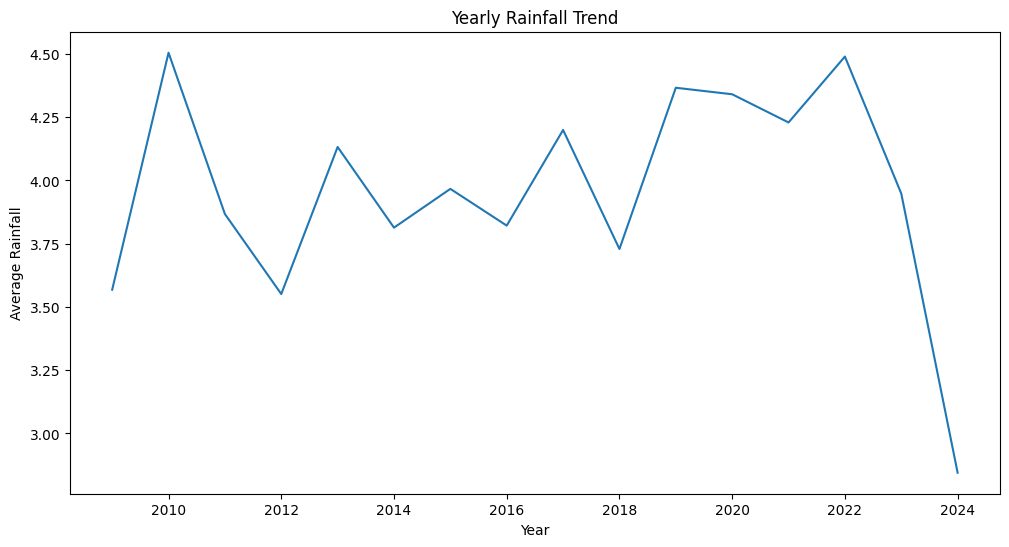

In [29]:
plt.figure(figsize=(12,6))
plt.plot(yearly_rain.index, yearly_rain.values)
plt.xlabel('Year')
plt.ylabel('Average Rainfall')
plt.title('Yearly Rainfall Trend')
plt.show()

#Line Graph
If the line goes up → rainfall increased


---


If the line goes down → rainfall decreased

How average rainfall changes year by year

In [33]:
#Statewise Rainfall

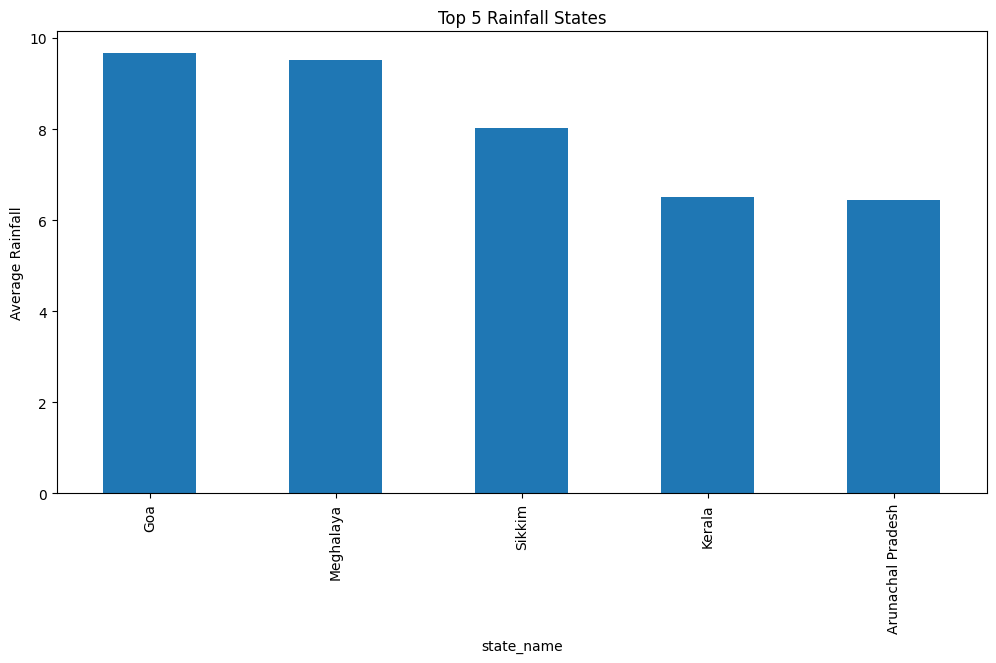

In [35]:
state_rain = df.groupby('state_name')['actual'].mean().sort_values(ascending=False)

state_rain.head(5).plot(kind='bar', figsize=(12,6))
plt.title('Top 5 Rainfall States')
plt.ylabel('Average Rainfall')
plt.show()

In [36]:
#Actual vs Normal Rainfall

In [37]:
import plotly.express as px

comparison = df.groupby('Year')[['actual','normal']].mean().reset_index()

fig = px.line(comparison, x='Year', y=['actual','normal'],
              title='Actual vs Normal Rainfall')

fig.show()

The graph compares:

How much rainfall actually happened
VS
What the normal rainfall should be

Actual > Normal → extra rainfall


Actual < Normal → low rainfall/drought

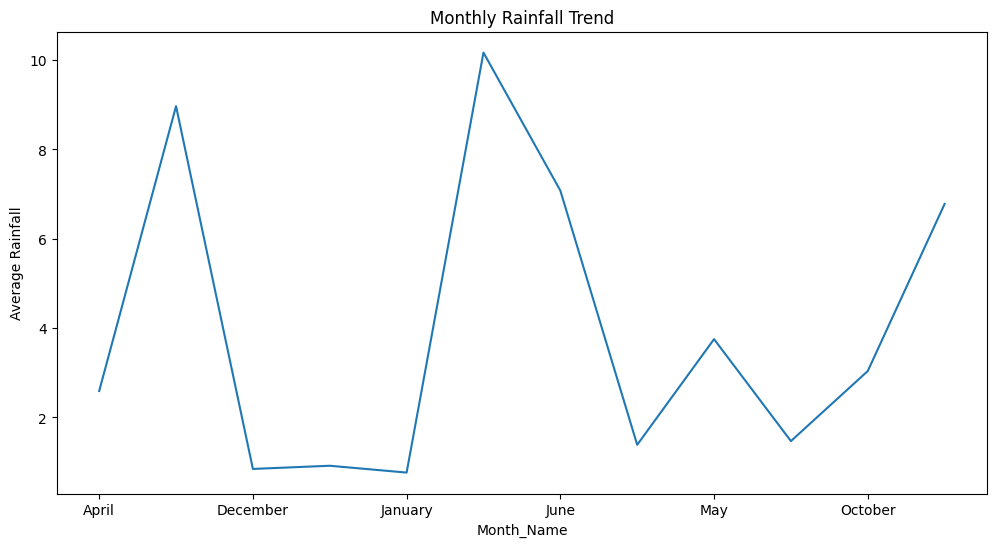

In [38]:
monthly = df.groupby('Month_Name')['actual'].mean()

monthly.plot(kind='line', figsize=(12,6))
plt.title('Monthly Rainfall Trend')
plt.ylabel('Average Rainfall')
plt.show()

this show peak monsoon month and less monsoon month

In [39]:
df.to_csv('cleaned_rainfall.csv', index=False)